In [ ]:
# comparação quatitativa de publicações Lula e Flávio Bolsonaro.

In [1]:
import pandas as pd
import requests
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
#carregar os dois data frames aqui e juntar em um só

In [9]:
df_lula = pd.read_json('dataset_instagram-scraper_2026-07-06_19-27-37-648.json')
df = pd.read_json('data.flavio.json')

In [ ]:
#limpar as colunas

In [10]:
df_lula_clean = df_lula.drop(columns=['dimensionsHeight', 'videoDuration', 'displayUrl', 'mentions', 'locationName', 'videoViewCount','isPinned', 'images', 'taggedUsers', 'firstComment', 'latestComments', 'videoPlayCount','inputUrl', 'coauthorProducers','productType','locationId','dimensionsWidth', 'musicInfo', 'originalWidth', 'shortCode', 'originalHeight', 'videoUrl','shortCode', 'hashtags', 'childPosts', 'ownerUsername', 'ownerId', 'audioUrl', 'alt', 'ownerFullName'])
df_clean_flavio = df.drop(columns=['dimensionsHeight', 'videoDuration', 'displayUrl', 'mentions', 'locationName', 'videoViewCount','isPinned', 'images', 'taggedUsers', 'firstComment', 'latestComments', 'videoPlayCount','inputUrl', 'coauthorProducers','productType','locationId','dimensionsWidth', 'musicInfo', 'originalWidth', 'shortCode', 'originalHeight', 'videoUrl','shortCode', 'hashtags', 'childPosts', 'ownerUsername', 'ownerId', 'audioUrl', 'alt', 'ownerFullName'])

In [ ]:
#organizar coluna de data 
#colocar em data time
#selecionar só ano 2026 
#e deixar coluna com meses.

In [13]:
df_lula_clean['date'] = df_lula_clean['timestamp'].dt.date
df_lula_clean["date"] = pd.to_datetime(df_lula_clean["date"])
df_lula_clean['date'].dt.year.unique()

array([2026], dtype=int32)

In [18]:
df_lula_clean['month'] = df_lula_clean['date'].dt.month
posts_month_lula = df_lula_clean['month'].value_counts(ascending=True)

In [22]:
df_clean_flavio['date'] = df_clean_flavio['timestamp'].dt.date
df_clean_flavio["date"] = pd.to_datetime(df_clean_flavio["date"])
df_flavio_2026 = df_clean_flavio[df_clean_flavio["date"].dt.year == 2026].reset_index(drop=True)
df_flavio_2026["date"].dt.year.unique()

array([2026], dtype=int32)

In [25]:
df_flavio_2026['month'] = df_flavio_2026['date'].dt.month
posts_month_flavio = df_flavio_2026['month'].value_counts(ascending=True)

In [ ]:
#juntar num mesmo df. #concat

In [44]:
df_lula_clean['politico'] = 'Lula'
df_flavio_2026['politico'] = 'Flávio'

df_comp = pd.concat([df_lula_clean, df_flavio_2026], ignore_index=True)

In [40]:
resumo = df_comp.groupby('politico').agg(
    media_comentarios=('commentsCount', 'mean'),
    media_curtidas=('likesCount', 'mean')
).round(0).astype(int)

resumo

,media_comentarios,media_curtidas
politico,,
Flávio,10285,177234
Lula,7421,124405


In [42]:
resumo.to_csv('medias_comentarios_curtidas.csv')

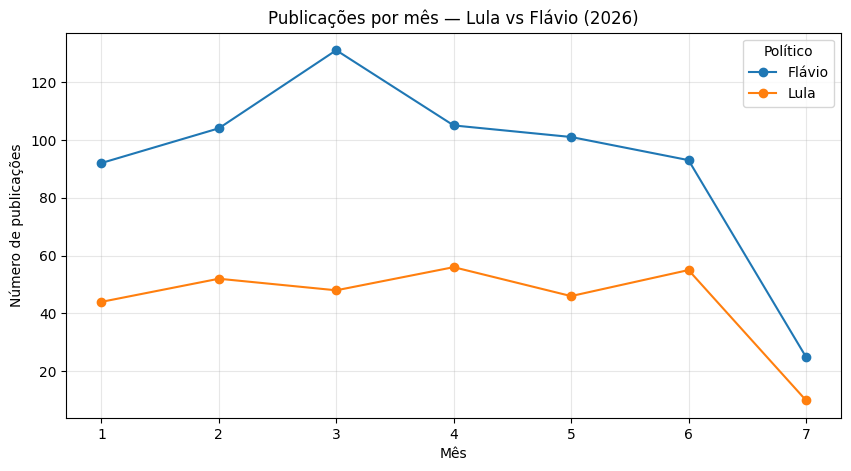

In [29]:
import matplotlib.pyplot as plt

posts_por_mes = df_comp.groupby(['month', 'politico']).size().unstack(fill_value=0)

posts_por_mes.plot(kind='line', marker='o', figsize=(10,5))
plt.title('Publicações por mês — Lula vs Flávio (2026)')
plt.xlabel('Mês')
plt.ylabel('Número de publicações')
plt.legend(title='Político')
plt.grid(alpha=0.3)
plt.show()

In [32]:
posts_por_mes.to_csv('posts_por_mes.csv')

In [ ]:
# comparar os cinco posts mais comentados e curtidos dos dois

In [46]:
top5_por_politico = (
    df_comp.sort_values('commentsCount', ascending=False)
    .groupby('politico')
    .head(5)
    [['politico', 'caption', 'commentsCount', 'date']]
)

top5_por_politico

,politico,caption,commentsCount,date
830,Flávio,A oração é o escudo do cristão. Vamos jejuar e...,123591,2026-03-13
586,Flávio,Sempre bate uma saudade enorme do tempo em que...,122426,2026-03-21
760,Flávio,"LULA ZOMBA DO POVO! \n\nO Carnaval é cultura, ...",120416,2026-02-16
505,Flávio,CPI DO BANCO MASTER JÁ! Chegou a hora de separ...,99107,2026-05-13
712,Flávio,Que esta mensagem toque o seu coração. Assista...,97799,2026-01-17
159,Lula,O Brasil é o único país do mundo com mais de 1...,59120,2026-04-08
36,Lula,Professor Carlo Ancelotti e jogadores da nossa...,57903,2026-06-13
288,Lula,"Uma noite inesquecível na Sapucaí. Niterói, Im...",43661,2026-02-16
84,Lula,Reunião muito produtiva com o presidente dos E...,40028,2026-05-07
268,Lula,"Conheci o Douglas, filho de diarista e de pedr...",38081,2026-01-15


In [51]:
top5_lula = df_comp[df_comp['politico'] == 'Lula'].nlargest(5, 'commentsCount')[['caption', 'commentsCount', 'date']]
top5_flavio = df_comp[df_comp['politico'] == 'Flávio'].nlargest(5, 'commentsCount')[['caption', 'commentsCount', 'date']]

In [52]:
top5_lula.to_csv('top5_lula.csv', index=False)
top5_flavio.to_csv('top5_flavio.csv', index=False)